[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



--- LDA ---
Tópico 0: presidente, brasil, vez, tentar, vídeos, dois, maçonaria, responde, toda, ligar
Tópico 1: grupo, presidente, avisem, novo, congresso, pra, vídeo, veja, querem, achando
Tópico 2: bolsonaro, churrasco, trabalhe, brasil, podcast, inteligência, ltda, políticos, vídeo, presidente
Tópico 3: brasil, pode, limites, lado, tudo, bolsonaro, turno, daqui, pouco, link
Tópico 4: censura, brasil, prévia, bolsonaro, veja, ministro, máximo, grupos, inteligência, link
In stage 0: transferred 58 clusters with 8 clusters populated
In stage 1: transferred 35 clusters with 8 clusters populated
In stage 2: transferred 37 clusters with 8 clusters populated
In stage 3: transferred 29 clusters with 8 clusters populated
In stage 4: transferred 38 clusters with 8 clusters populated
In stage 5: transferred 36 clusters with 8 clusters populated
In stage 6: transferred 34 clusters with 8 clusters populated
In stage 7: transferred 32 clusters with 8 clusters populated
In stage 8: transferred 35

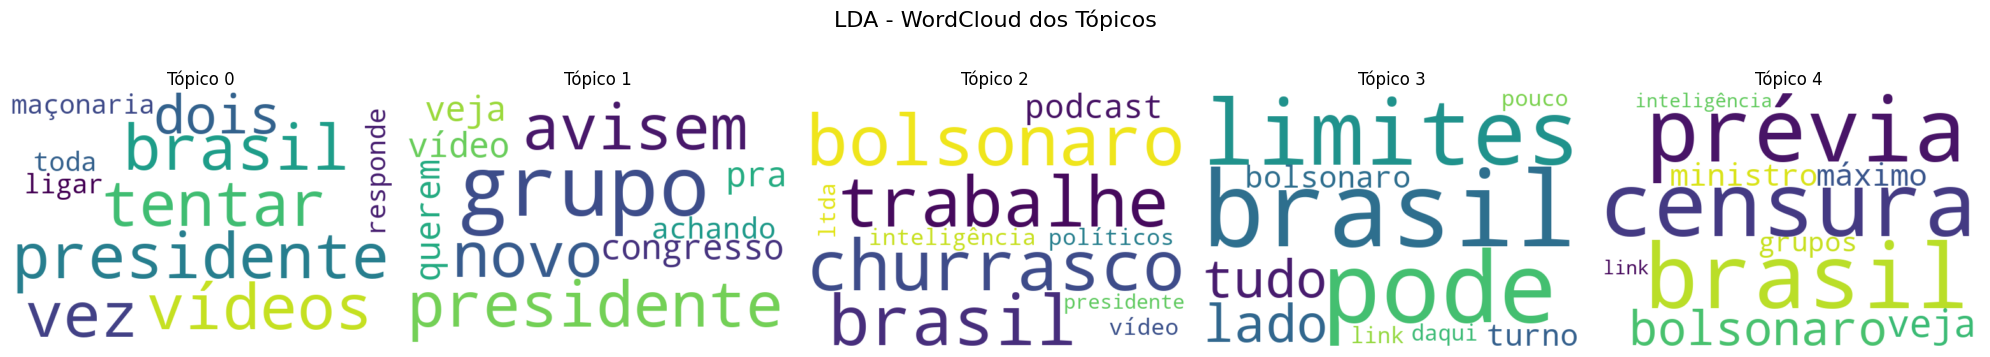

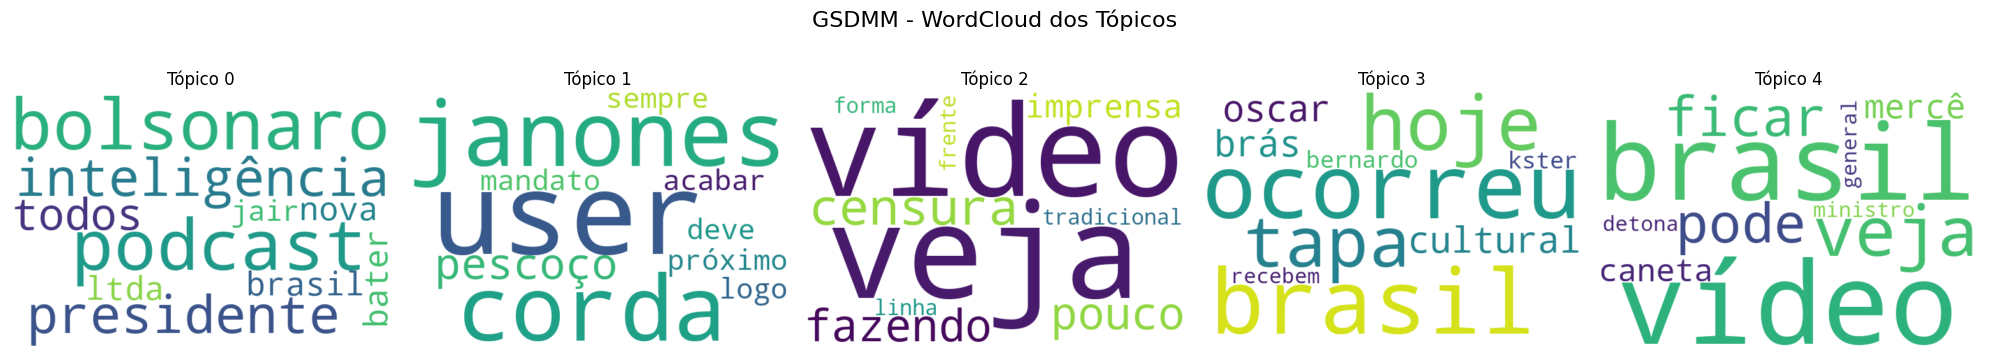

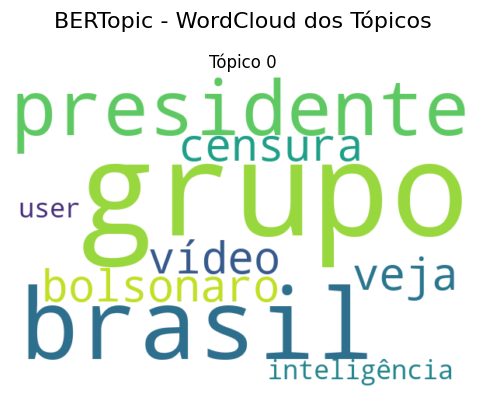

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora
from gensim.models.ldamodel import LdaModel
from bertopic import BERTopic
from gsdmm import MovieGroupProcess

nltk.download('stopwords')
from nltk.corpus import stopwords

# === 1. LEITURA DO CSV ===
df = pd.read_csv("fakeTelegram.BR_2022.short.csv")
df = df[df['text_content_anonymous'].notnull()]
texts = df['text_content_anonymous'].astype(str).tolist()

# === 2. PRÉ-PROCESSAMENTO ===
stopwords_pt = set(stopwords.words('portuguese'))

def preprocess(text):
    text = re.sub(r"http\S+", "", text)  # remove links
    text = re.sub(r"[^a-zA-ZáéíóúãõâêôçÁÉÍÓÚÂÊÔÃÕÇ ]", "", text)  # remove pontuação
    text = text.lower()
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords_pt and len(word) > 2]
    return tokens

processed_texts = [preprocess(t) for t in texts]

def display_topics(model_name, topics):
    print(f"\n--- {model_name} ---")
    for i, topic in enumerate(topics):
        print(f"Tópico {i}: {', '.join(topic)}")

# === 3. LDA ===
dictionary = corpora.Dictionary(processed_texts)
corpus = [dictionary.doc2bow(text) for text in processed_texts]
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, random_state=42, passes=10)
lda_topics = []
for i in range(5):
    topic = lda_model.show_topic(i, topn=10)
    lda_topics.append([word for word, prob in topic])
display_topics("LDA", lda_topics)

# === 4. GSDMM ===
vocab = set(word for text in processed_texts for word in text)
docs = [" ".join(text) for text in processed_texts]
docs_tokenized = [doc.split() for doc in docs]

gsdmm = MovieGroupProcess(K=8, alpha=0.1, beta=0.3, n_iters=30)
y = gsdmm.fit(docs_tokenized, len(vocab))

def get_gsdmm_topics(model, top_n_words=10):
    topics = []
    for topic_num in range(model.K):
        if model.cluster_doc_count[topic_num] == 0: continue
        word_probs = model.cluster_word_distribution[topic_num]
        top_words = sorted(word_probs.items(), key=lambda x: x[1], reverse=True)[:top_n_words]
        topics.append([word for word, _ in top_words])
    return topics

gsdmm_topics = get_gsdmm_topics(gsdmm)
display_topics("GSDMM", gsdmm_topics)

# === 5. BERTopic ===
texts_cleaned = [" ".join(text) for text in processed_texts]
topic_model = BERTopic(language="portuguese", calculate_probabilities=True)
topics, probs = topic_model.fit_transform(texts_cleaned)
bertopic_topics = [topic_model.get_topic(i) for i in range(len(set(topics)) - 1)]

print("\n--- BERTopic ---")
for i, topic in enumerate(bertopic_topics):
    if topic:
        print(f"Tópico {i}: {', '.join([word for word, _ in topic[:10]])}")

def plot_wordcloud(topics, model_name):
    num_topics = min(5, len(topics))
    fig, axes = plt.subplots(1, num_topics, figsize=(20, 4))

    if num_topics == 1:
        axes = [axes]

    for i, topic in enumerate(topics[:num_topics]):
        wc = WordCloud(width=600, height=400, background_color='white').generate(" ".join(topic))
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'Tópico {i}')
    plt.suptitle(f'{model_name} - WordCloud dos Tópicos', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_wordcloud(lda_topics, "LDA")
plot_wordcloud(gsdmm_topics, "GSDMM")
plot_wordcloud([[word for word, _ in topic[:10]] for topic in bertopic_topics if topic], "BERTopic")
